<a href="https://colab.research.google.com/github/elianolaya/Repositorio/blob/main/Keppler_regresion_lineal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Regresión lineal por mínimos cuadrados


---
---

### Definición

La [regresión lineal](https://es.wikipedia.org/wiki/Regresi%C3%B3n_lineal) es una técnica matematcia que se utiliza para describir una *variable de respuesta* en función de una o más *variables predictoras*. Puede ayudar a comprender y predecir el comportamiento de sistemas complejos o analizar datos experimentales, financieros, biológicos, etc.

- En una *regresión lineal simple* se utiliza un único predictor $X$, para describir una variable de respuesta $Y$,  lo cual se realiza a través de la ecuación general
$$Y = m X + b  $$
en la que $b$ (*intercepto*) y $m$ (*pendiente*) son los parámetros del modelo y $\epsilon$ representa el término de error.

- Los parámetros del modelo, también llamados *coeficientes de regresión*, se deben calcular a partir del conjunto de datos u observaciones disponibles $\{(x_i,y_i),\,i=1,\dots,n\}$ y el término de error mide la diferencia entre las predicciones del modelo y las observaciones reales.

- La estimación de los parámetros $m$ y $b$ se realiza a través del *método de mínimos cuadrados*.

---
Método de mínimos cuadrados

* La idea del método es minimizar la suma de todas las diferencias cuadráticas entre los valores generados ($Y_i$) por la función modelo y los correspondientes valores de los datos reales ($y_i$).

- En otras palabras el objetivo del método es  encontrar los valores de $\beta_0$ y $\beta_1$ tales que la función  
$$E(m, b) = \sum_{i=1}^n\left[ y_i - f(x_i) \right]^2 = \sum_{i=1}^n\left[ y_i - ( m x_i + b)\right]^2$$
 tenga el mínimo valor posible.

- Para evaluación los  parámetros a partir de los datos hay que minimizar $E(m, b)$

- Al realizar el proceso de minimización de la función $E(m, b)$ se obtiene:

  - Valor estimado del intercepto:
  
  $$b = \frac{S_{xx}\cdot S_y  - S_{xy}\cdot S_x }{n\cdot S_ {xx} - S_x^2  } $$

   - Valor estimado de la pendiente:
  $$ m =  \frac{n\cdot S_{xy} - S_x\cdot S_y }{n\cdot S_{xx}- S_x^2}, \color{white}{........} $$

- En las expresiones anteriores  se han definido las siguientes sumatorias
  $$ S_x = \sum_{i=1}^{n} x_i, \hspace{3ex}  
  S_y =   \sum_{i=1}^{n} y_i, \hspace{3ex}
  S_{xx} =   \sum_{i=1}^{n} x_i^2, \hspace{3ex}
  S_{xy} = \sum_{i=1}^{n} x_i y_i, $$

  las cuales se calculan usando los datos disponibles $\{(x_i,y_i)\}$.



---
### Ejemplo

En la tabla se muestran algunas medidas de estatura y masa corporal que se tomaron a un determinado grupo de personas practicantes de baloncesto.

 Estatura | Peso
--------|-----------
(m)  | (kg)
1.55 |  51
1.57 |  50
1.62 |  55
1.68 |  52
1.75 |  60
1.75 |  68
1.81 |  78
1.83 |  91
1.87 |  84
1.89 |  81
1.90 |  90
1.92 | 105
1.95 |  95
1.95 |  99
1.99 | 100
2.02 | 101

**Problema**

- Determine una relación entre la estatura (*variable predictora*) y la masa corporal (*variable de respuesta*) para el grupo de personas seleccionadas. No olvide indicar las unidades de los parámetros del modelo ($m$ y $b$)



**Solución**

> **1. Datos de entrada - Visualización**

>  Antes de empezar con un análisis de regresión es importante hacer un análisis exploratorio de los datos. En el caso de que se tenga la dependencia entre dos o tres variables, un gráfico de dispersión es apropiado para darse una primera idea de la relación entre ellas.

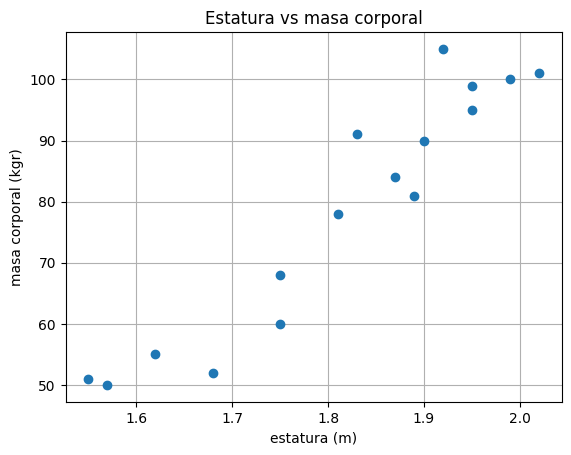

In [ ]:
# Importar las librerías necesarias
import matplotlib.pyplot as plt
import numpy as np


# Datos representados en la tabla (usando arreglos)
estatura      = np.array([1.55, 1.57, 1.62, 1.68, 1.75, 1.75,	1.81,	1.83,	1.87,	1.89,	1.90,	1.92,	1.95,	1.95,	1.99,	2.02])
masa_corporal = np.array([51,	50,	55,	52,	60,	68,	78,	91,	84,	81,	90,	105,	95,	99,	100,	101])




# Genera una gráfica "estatura vs masa_corporal""
plt.plot(estatura,masa_corporal,'o')

plt.xlabel('estatura (m)')

plt.ylabel('masa corporal (kgr)')

plt.title('Estatura vs masa corporal')

plt.grid()

plt.show()


> **2. Análisis de regresión ("Ajuste lineal")**

>  Se supone una relación lineal entre las variables:
   $$y = m \cdot x + b,$$

> con $y= \text{masa corporal}$ $x= \text{estatura}$.  La evaluación de los parámetros de la regresión ($b = $ intercepto  y $m = $pendiente) parte de la evaluación de las sumatorias $S_x$, $S_y$, $S_{xx}$ y $S_{xy}$ definidas arriba  en términos del conjunto de datos $\{ (x_i,y_i)\}^{n}_{i=1}$

In [ ]:
# Evaluación de las sumatorias necesarias para
# calcular los coeficientes de regresión

#Aqui
x = estatura
y = masa_corporal

#---------------------------------------------------------
#Calculo de la pendiente (m) y el intercepto (b) de la linealizacion
n = len(x)

#donde almacenaremos los valores de las sumas
suma_xi  = 0
suma_yi  = 0
suma_xixi= 0
suma_xiyi= 0

for i in range( n ):
    suma_xi   += x[i]
    suma_yi   += y[i]
    suma_xixi += x[i]**2
    suma_xiyi += x[i]*y[i]


#aplicado las formulas
m = (n  * suma_xiyi      - suma_xi   * suma_yi) / (n * suma_xixi - suma_xi**2)

b = (suma_xixi * suma_yi - suma_xiyi * suma_xi) / (n * suma_xixi - suma_xi**2)


#Linea recta aproximada
F = m * x + b #note que aqui toca transformar la lista de x a un arreglo!

#---------------------------------------------------------



In [ ]:

print('Modelo: masa_corporal = m * estatura + b \n')
print('Parámetro de regresión b (intercepto) = %7.3f  ' %(b), 'kg \n')
print('Parámetro de regresión m (pendiente)  = %7.3f  '%(m), 'kg/m ')


Modelo: masa_corporal = m * estatura + b 

Parámetro de regresión b (intercepto) = -152.168   kg 

Parámetro de regresión m (pendiente)  = 127.184   kg/m 


> **3. Comparación del modelo con las observaciones**

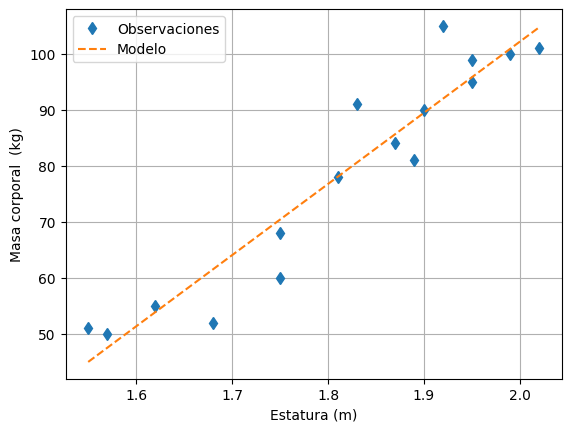

In [ ]:
# Determinación de la predicción del modelo



# Grafica los datos observados
plt.plot(x, y, 'd', label='Observaciones')


# Grafica el modelo obtenido por regresión lineal
plt.plot(x, F,'--', label='Modelo')


plt.xlabel('Estatura (m)')
plt.ylabel('Masa corporal  (kg)')

#Activar Legenda
plt.legend()


plt.grid()
plt.show()

## Algunos errores

**4. Error cuadrático medio (MSE)**

Existen muchas formas de calcular errores en un proceso de regresion. Una de las mas comunes es la raiz del error cuadratico medio, el cual esta definido como:  

$$MSE = \sqrt{ \dfrac{1}{n} \sum^{n}_{i}  | y_i - f(x_i)|^2 }$$

Entre mas cerca a cero este error, mejor sera nuesta regresión.

In [ ]:
#Calculamos el error cuadratico medio

MSE = np.sqrt(  np.sum( (y-F)**2 ) / n )

print( "El error MSE es:", MSE )


El error MSE es: 6.15273210522792


**Error porcentual medio absoluto (MAPE):**


$$
\mathrm{MAPE} = \frac{100\%}{n} \sum_{i=1}^n \left| \frac{y_i - f(x_i)}{y_i} \right|
$$


In [ ]:
MAPE =  (100/n) *  np.sum( np.abs( (y-F)/y )  )

print( "El error MAPE es:", MAPE, "%")


El error MAPE es: 6.377024504130263 %


**Coeficiente de correlación R**:

La fórmula del coeficiente de correlación $R$ viene directamente de la definición de correlación como una covarianza normalizada (este concepto se aclara en estadistica):

$$
R = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^n (x_i - \bar{x})^2} \; \sqrt{\sum_{i=1}^n (y_i - \bar{y})^2}}
$$



**Significado**

"Mide" que tan relaciónados de manera lineal estan un conjunto de datos de la forma ${ (x_i,y_i) }^{n}_{i=1}$. Está acotado:

$$
-1 \le R \le 1
$$

**Donde:**

- $R = 1$ → relación lineal **positiva perfecta** entre los datos.
- $R = -1$ → relación lineal **negativa perfecta**.
- $R \approx 0$ → no hay relación lineal significativa entre los datos.



In [ ]:
x_mean = np.mean(x)
y_mean = np.mean(y)

numerador   = np.sum((x - x_mean) * (y - y_mean))
denominador = np.sqrt(np.sum((x - x_mean)**2) * np.sum((y - y_mean)**2))

R  = numerador / denominador
print(f"Coeficiente de correlacion = {R:.1f}")


Coeficiente de correlacion = 0.9370


Para tener en cuenta respecto a la interpretación del valor de R:

∣R∣ | Interpretación común |
|---------------|----------------------|
| 0.0 – 0.2 | Muy débil o nula |
| 0.2 – 0.4 | Débil |
| 0.4 – 0.6 | Moderada |
| 0.6 – 0.8 | Fuerte |
| 0.8 – 1.0 | Muy fuerte |


<br>

<br>

##**Bonus**

1. Ver las funciones de numpy

In [ ]:
import numpy as np
np.__all__

['less',
 'logical_or',
 'bitwise_count',
 'triu',
 'column_stack',
 'polyint',
 'trunc',
 'longdouble',
 'flipud',
 'complex128',
 'copy',
 'minimum',
 'amax',
 'array_split',
 'cosh',
 'real_if_close',
 'integer',
 'correlate',
 'angle',
 'convolve',
 'int16',
 'strings',
 'nanmean',
 'real',
 'longlong',
 'nanstd',
 'diagflat',
 'select',
 'nanmin',
 'nested_iters',
 'not_equal',
 'acosh',
 'arccos',
 'ScalarType',
 'stack',
 'bytes_',
 'number',
 'signbit',
 'nanprod',
 'array',
 'acos',
 'seterrcall',
 'round',
 'kaiser',
 'tril_indices',
 'partition',
 'ix_',
 'array_str',
 'log2',
 'polyfit',
 'object_',
 'choose',
 'count_nonzero',
 'tri',
 'ctypeslib',
 'isclose',
 'bitwise_xor',
 'set_printoptions',
 'uint8',
 'iterable',
 'csingle',
 'diff',
 'broadcast',
 'ulong',
 'cov',
 'flip',
 'histogram2d',
 'subtract',
 'matrix',
 'histogram_bin_edges',
 'polyval',
 'int32',
 'percentile',
 'exceptions',
 'atleast_2d',
 'median',
 'swapaxes',
 'compress',
 'require',
 '__version__',


2. Pedir info de una funcion en particular

In [ ]:
help(np.cos)

Help on ufunc:

cos = <ufunc 'cos'>
    cos(x, /, out=None, *, where=True, casting='same_kind', order='K', dtype=None, subok=True[, signature])

    Cosine element-wise.

    Parameters
    ----------
    x : array_like
        Input array in radians.
    out : ndarray, None, or tuple of ndarray and None, optional
        A location into which the result is stored. If provided, it must have
        a shape that the inputs broadcast to. If not provided or None,
        a freshly-allocated array is returned. A tuple (possible only as a
        keyword argument) must have length equal to the number of outputs.
    where : array_like, optional
        This condition is broadcast over the input. At locations where the
        condition is True, the `out` array will be set to the ufunc result.
        Elsewhere, the `out` array will retain its original value.
        Note that if an uninitialized `out` array is created via the default
        ``out=None``, locations within it where the condi



# Regresion lineal usando el modulo scipy

In [ ]:
! pip

In [ ]:
from scipy import stats   # Carga el módulo de herramientas estadísticas

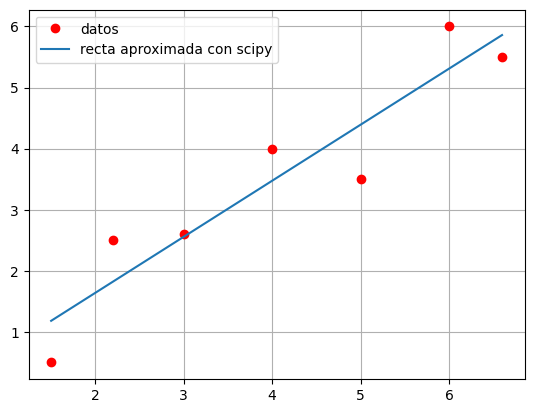

In [ ]:
#datos que queremos ajustar
x = [1.5  ,2.2  ,3 ,4 ,5  ,6,6.6]
y = [0.5,2.5,2.6 ,4 ,3.5,6,5.5]


#Haciendo la regresion lineal con scipy
regresion_lineal = stats.linregress(x,y)

# Resultados del análisis
b2 = regresion_lineal.intercept   # Intercepto
m2 = regresion_lineal.slope       # Pendiente


L2 =  m2 * np.array(x)  + b2


#--------------graficando---------------------------
#Graficando las parejas de datos
plt.plot(  x  , y , "or" , label="datos" )


#Graficando la recta segun m y b
plt.plot(  x , L2 , label="recta aproximada con scipy"  )


#mostrando las legendas del grafico
plt.grid()
plt.legend()

#Mostrando el gráfico
plt.show()


# **Regla de la linea horizontal para el ajuste ajuste de datos**

In [ ]:
# Generar datos de ejemplo
x = np.linspace(0, 20, 100)  # Valores de x entre -10 y 10
y = -(x-10)**2 + 120  # Relación cuadrática con un máximo en (0, 50)

# Agregar algo de ruido aleatorio a los datos
np.random.seed(42)
ruido = np.random.normal(scale=2, size=x.shape)
y = y + ruido

**Veamos el grafico de estos datos**

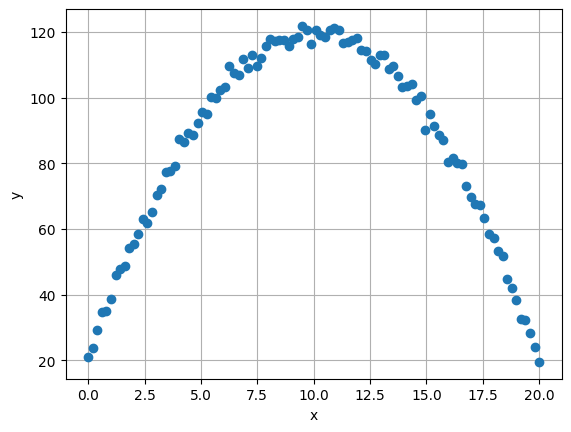

In [ ]:

# Genera una gráfica "estatura vs masa_corporal""
plt.plot(x,y,'o')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

**Analisis**

Claramente, los datos tienen una relación polinomial!

$$ y = b x^a $$

Por lo tanto, haciendo el cambion de variable obtenemos la recta

$$ w = a z + B $$


Donde
- $ w= \ln y $
- $ z= \ln x $
- $ B = \ln b $


si graficamos los datos obtenemos:

<ipython-input-6-7f668ed40545>:4: RuntimeWarning: divide by zero encountered in log
  z = np.log(x)


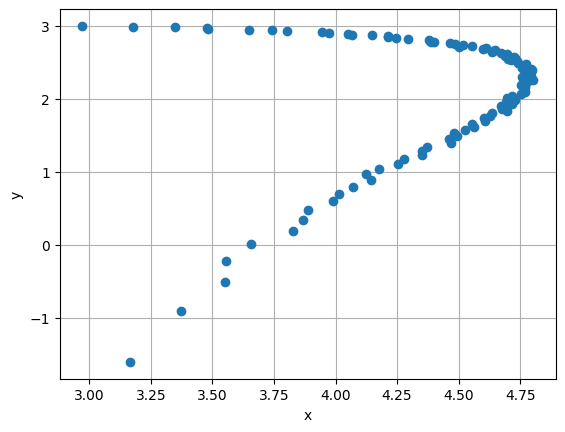

In [ ]:
#----------Cambio de Variable ---------
w = np.log(y)

z = np.log(x)
#--------------------------------------


# Genera una gráfica "estatura vs masa_corporal""
plt.plot(w,z,'o')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

NO obtenemos nada de la transformación :(.....por que para esto si latendencia de los datos originales es claramente parecido a una parabola????

**Respuesta:**

Para hacer el cambio de variable y que tengamos una tendencia lineal, TENEMOS que tener una tendencia de datos 1 a 1. Es decir, que para un solo valor de X corresponda un solo valor de Y. Graficamente, esto se ve con la prueba de la recta horizontal!

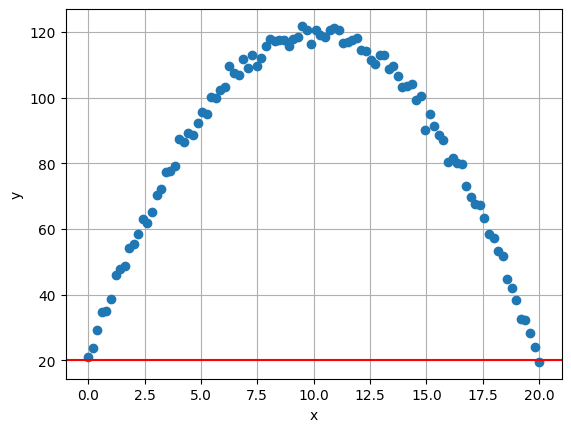

In [ ]:
# Genera una gráfica "estatura vs masa_corporal""
plt.plot(x,y,'o')

#linea horizontal
plt.axhline(y=20, color='r' )

plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

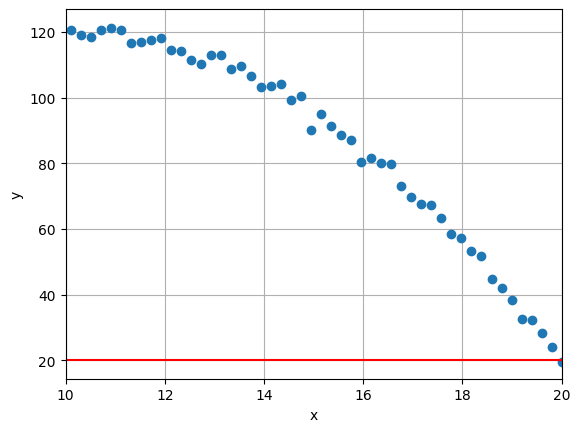

In [ ]:
# Genera una gráfica "estatura vs masa_corporal""
plt.plot(x,y,'o')

#linea horizontal
plt.axhline(y=20, color='r' )

plt.xlabel('x')
plt.ylabel('y')

plt.xlim([10,20])

plt.grid()
plt.show()

Debemos entonces DIVIDIR el conjunto de datos y analizar los puntos que satisfagan la relacion 1 a 1

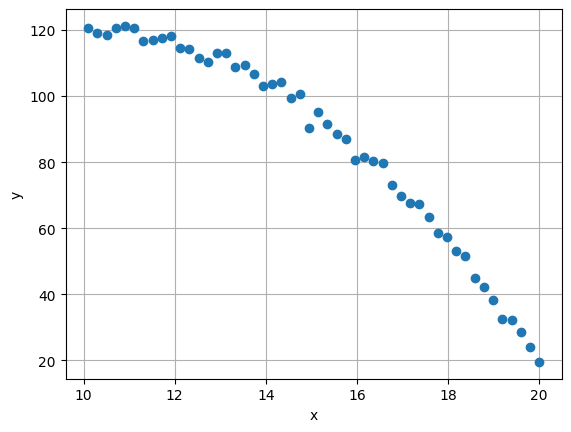

In [ ]:
# Calcular el índice de corte para la mitad superior
indice_corte = len(x) // 2 #esta division toma la parte entera de la division


# Tomar la mitad superior del arreglo
X_mitad_superior = x[indice_corte:]


# Tomar la mitad superior del arreglo
Y_mitad_superior = y[indice_corte:]


plt.plot(X_mitad_superior,Y_mitad_superior,'o')


plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

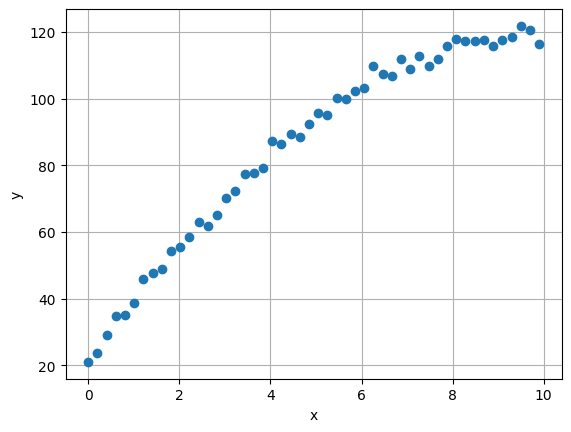

In [ ]:
#tambien podemos tomar la mitad inferior!


# Tomar la mitad superior del arreglo
X_mitad_inferior = x[:indice_corte]


# Tomar la mitad superior del arreglo
Y_mitad_inferior = y[:indice_corte]


plt.plot(X_mitad_inferior,Y_mitad_inferior,'o')


plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

Hacemos el cambio de variable con cualquiera de las dos mitades! Por ejemplo, tomemos la mitad inferior:

<ipython-input-134-90bfd8adf93f>:3: RuntimeWarning: divide by zero encountered in log
  Z_inferior = np.log(X_mitad_inferior)


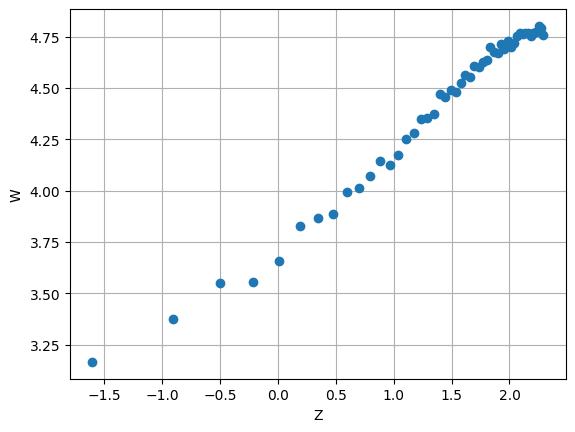

In [ ]:
W_inferior = np.log(Y_mitad_inferior)

Z_inferior = np.log(X_mitad_inferior)


plt.plot(Z_inferior,W_inferior,'o')


plt.xlabel('Z')
plt.ylabel('W')
plt.grid()
plt.show()

Lo cual si TIENE tendencia lineal!!!!